In [ ]:
import os
from collections import defaultdict

import numpy as np
from astropy.io import fits

import numpy as np
import pandas as pd

from astropy.convolution import convolve
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.psf import IntegratedGaussianPRF


# ==============================
# 設定：データが入っているディレクトリ
# ==============================
base_dir = "./FOCUSING_20250915"

# ==============================
# 1. ファイルを group_id ごとにまとめる
#    group_dict["00012"]["fits"] → [(idx, path), ...]
#    group_dict["00012"]["meta"] → "...._00012_meta.json"
# ==============================
group_dict = defaultdict(lambda: {"fits": [], "meta": None})

for fname in os.listdir(base_dir):

    # 必要なら prefix で絞る（不要ならこの if は消してOK）
    if not fname.startswith("focustest_gcode4_5000_20250915_"):
        continue

    fpath = os.path.join(base_dir, fname)
    base, ext = os.path.splitext(fname)
    parts = fname.split("_")

    # 例:
    # focustest_gcode4_5000_20250915_00012_4.fits
    # focustest_gcode4_5000_20250915_00012_meta.json
    # → parts[-2] が "00012"
    group_id = parts[-2]

    # FITS ファイル
    if ext == ".fits":
        # parts[-1] は "4.fits" なので、".fits" を外して index にする
        idx_str = os.path.splitext(parts[-1])[0]
        idx = int(idx_str)
        group_dict[group_id]["fits"].append((idx, fpath))

    # meta.json
    elif fname.endswith("_meta.json"):
        group_dict[group_id]["meta"] = fpath

# index 順にソートしておくと後で扱いやすい
for gid, entry in group_dict.items():
    entry["fits"].sort(key=lambda x: x[0])

# ==============================
# 2. 各 group_id ごとに FITS を読み込む
#    images_dict["00012"] → shape = (n_frames, ny, nx)
# ==============================
images_dict = {}   # 画像本体
meta_dict   = {}   # meta ファイルパス（必要なら中身を読む用）

for gid, entry in group_dict.items():
    image_list = []

    for idx, fpath in entry["fits"]:
        print(f"[{gid}] Loading idx={idx}: {fpath}")
        with fits.open(fpath) as hdul:
            # HSC の場合は拡張1が画像なことが多いので [1] を使用
            image_list.append(hdul[1].data)

    if image_list:
        images_dict[gid] = np.array(image_list)  # (n_frames, ny, nx)

    meta_dict[gid] = entry["meta"]

# ==============================
# 3. 使い方の例
# ==============================
# 例: group_id "00012" の画像スタックを取り出す
if "00012" in images_dict:
    imgs_00012 = images_dict["00012"]   # imgs_00012.shape → (n_frames, ny, nx)
    print("00012 stack shape:", imgs_00012.shape)
    print("00012 meta file:", meta_dict["00012"])
else:
    print("group_id '00012' は見つかりませんでした")


In [4]:
print(images_dict.keys())

dict_keys(['00008', '00002', '00007', '00001', '00006', '00010', '00012', '00011', '00000', '00009', '00003', '00005', '00004'])


In [5]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

def show_focus_group(image_dict, group_id, vmin=75, vmax=150):
    """
    image_dict[group_id] 内の画像を、
    元コードと同じ 1x6 グリッドで表示する
    """

    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found.")
        return

    image_list = image_dict[group_id]   # shape = (N, H, W)
    n_images = len(image_list)

    # --- Figure レイアウト（あなたの元コードをそのまま踏襲） ---
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    # --- 画像ごとの描画 ---
    for i, ax in enumerate(axs):
        ax.set_title(f"CMOS {i}", ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(image_list[i], vmin=vmin, vmax=vmax, origin='lower')

    plt.show()


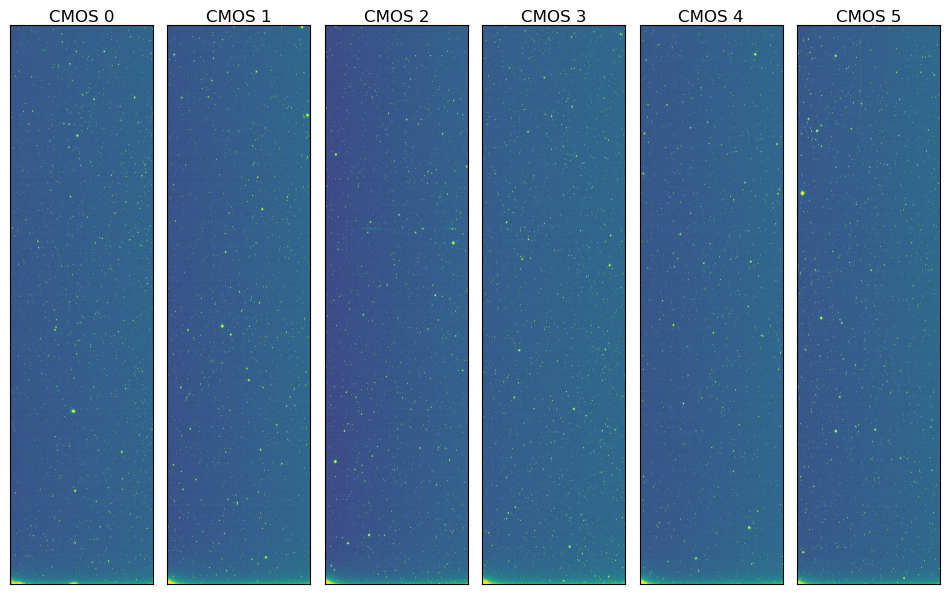

In [6]:
show_focus_group(images_dict, "00012")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

def show_focus_group_with_detections(image_dict, det_results, group_id,
                                     vmin=75, vmax=150, s=5):
    """
    すでに Dask などで計算済みの det_results を使って、
    image_dict[group_id] の各CMOS画像に検出位置を重ねて表示する。

    Parameters
    ----------
    image_dict : dict
        {group_id: [img0, img1, ...]} の形の辞書
    det_results : dict
        run_detection_on_all_local / run_detection_on_all_dask が返した結果。
        det_results[gid] は各フレームの dict のリストを想定。
    group_id : hashable
        表示したいキー（例: "00012"）
    vmin, vmax : float
        imshow の表示レンジ（全コマで揃える）
    s : float
        検出マーカーのサイズ（scatter の s）
    """

    # --- 存在チェック ---
    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found in image_dict.")
        return

    if group_id not in det_results:
        print(f"Group ID {group_id} was not found in det_results.")
        return

    image_list = image_dict[group_id]
    n_images = len(image_list)

    # det_results[group_id] を index → record の dict にしておく
    frame_results = det_results[group_id]  # list of dicts
    idx_to_record = {rec["index"]: rec for rec in frame_results}

    # --- Figure レイアウト（元の show_focus_group と同じ 1 x N グリッド） ---
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    # --- 各CMOSごとに描画 ---
    for i, (img, ax) in enumerate(zip(image_list, axs)):
        ax.set_title(f"CMOS {i}", ha='center', va='center', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

        # 画像本体
        ax.imshow(img, vmin=vmin, vmax=vmax, origin='lower', cmap='gray')

        # このフレームに対応する detection 結果があればマーカーを描画
        if i in idx_to_record:
            det_smooth = idx_to_record[i]["table"]  # pandas DataFrame
            if len(det_smooth) > 0:
                ax.scatter(
                    det_smooth["xcentroid"],
                    det_smooth["ycentroid"],
                    s=s,
                    edgecolors='red',
                    facecolors='none',  # 中抜き円にしたい場合
                    lw=0.5,
                )

    plt.show()


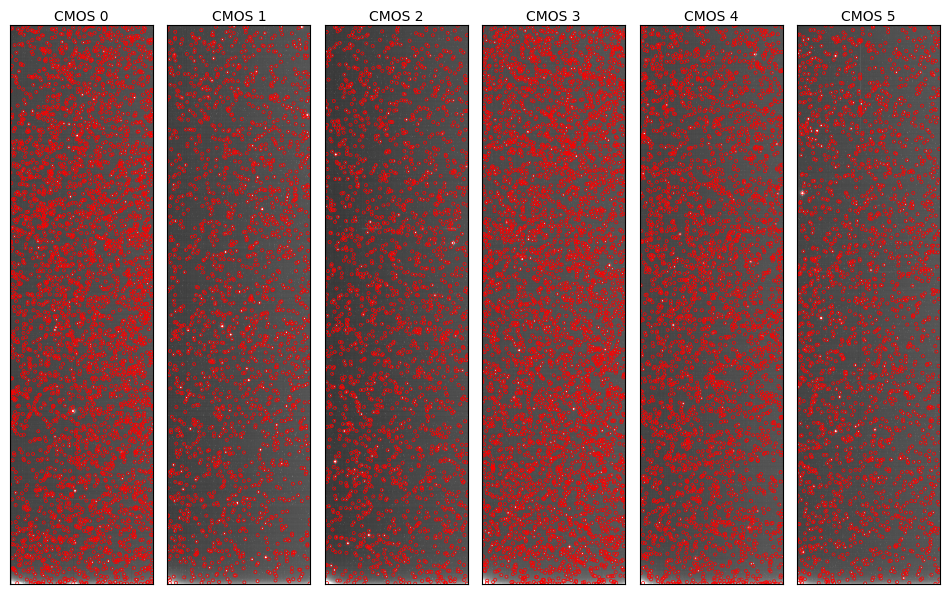

In [17]:
# 例: すでに images_dict と det_results があるとする
# det_results = run_detection_on_all_local(images_dict, nrows, ncols)

show_focus_group_with_detections(
    images_dict,
    det_results,
    "00012",   # ← dict の key を指定
    vmin=75,
    vmax=150,
    s=5,
)


In [13]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

def show_focus_group_with_detection(image_dict, group_id, nrows, ncols,
                                    vmin=None, vmax=None, s=5):
    """
    image_dict[group_id] に入っている画像それぞれに対して
    detection() を実行し、検出した天体の位置にマーカーを打って表示する。

    Parameters
    ----------
    image_dict : dict
        {group_id: [img0, img1, ...]} の形の辞書
    group_id : hashable
        表示・検出したいキー（例: '20241001_001' など）
    nrows, ncols : int
        detection() 内で使っている分割数（既存の detection と同じ引数）
    vmin, vmax : float or None
        imshow の表示レンジ。None の場合は画像ごとに percentile から自動決定。
    s : float
        マーカーのサイズ（scatter の s）
    """

    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found in image_dict.")
        return

    image_list = image_dict[group_id]
    n_images = len(image_list)

    # Figure レイアウト（元の show_focus_group を踏襲）
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    for i, (img, ax) in enumerate(zip(image_list, axs)):
        # まず detection を実行
        segm, cat, det_smooth = detection(img, nrows=nrows, ncols=ncols)

        # 表示レンジの決定
        if vmin is None:
            vmin_i = np.percentile(img, 5)
        else:
            vmin_i = vmin

        if vmax is None:
            vmax_i = np.percentile(img, 99)
        else:
            vmax_i = vmax

        ax.set_title(f"CMOS {i}", ha='center', va='center', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

        # 画像本体
        ax.imshow(img, vmin=vmin_i, vmax=vmax_i, origin='lower', cmap='gray')

        # 検出天体の位置にマーク
        ax.scatter(
            det_smooth["xcentroid"],
            det_smooth["ycentroid"],
            s=s,
            edgecolors='red',
            facecolors='none',  # 中抜きにしたい場合
            lw=0.5,
        )

    plt.show()


/home/satoksk/miniconda3/envs/astro/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36689 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:40495' processes=14 threads=28, memory=188.64 GiB>
検出した天体の数: 3552
検出した天体の数: 1992
検出した天体の数: 1967
検出した天体の数: 4058
検出した天体の数: 3096
検出した天体の数: 1976


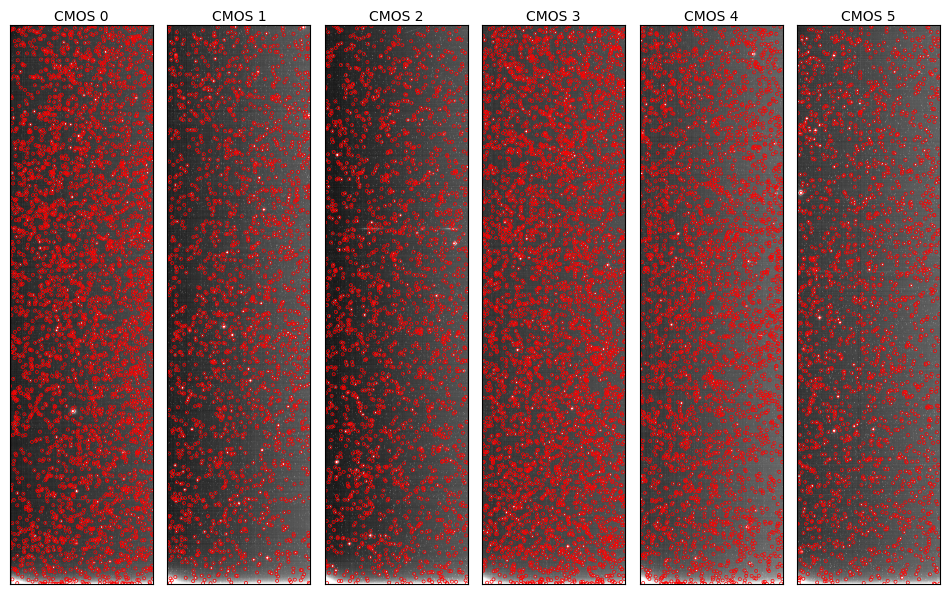

In [14]:
from dask.distributed import Client

client = Client(processes=True, n_workers=14, threads_per_worker=2)
print(client)

nrows, ncols = 4, 5
group_id = list(images_dict.keys())[0]  # 例：一つ適当に選ぶ

show_focus_group_with_detection(images_dict, group_id, nrows, ncols)
